In [ ]:
!pip install pillow

In [ ]:
from PIL import Image

In [ ]:
image_colored = Image.open("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Image.JPG")

In [ ]:
print("Format:", image_colored.format)
print("Mode:", image_colored.mode)
print("Size:", image_colored.size)

Format: JPEG
Mode: RGB
Size: (1536, 2048)


In [ ]:
image_colored = image_colored.convert("RGB")
print(image_colored.mode)

RGB


**Gray Scale Image**

In [ ]:
image_grayed = image_colored.convert('L')
display(image_grayed)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print(image_grayed.size)
print(image_grayed.mode)
print(image_grayed.format)

(1536, 2048)
L
None


In [ ]:
width, height = image_grayed.size
channels = len(image_grayed.getbands())

print(f"iamge shape(gray): ({height}, {width}, {channels})")

image_size_grayed = width * height * 1
print(f"image size(gray): {image_size_grayed}")

iamge shape(gray): (2048, 1536, 1)
image size(gray): 3145728


In [ ]:
width, height = image_colored.size
channels = len(image_colored.getbands())

print(f"iamge shape(RGB): ({height}, {width}, {channels})")

image_size_colored = width * height * 3
print(f"image size(RGB): {image_size_colored}")

iamge shape(RGB): (2048, 1536, 3)
image size(RGB): 9437184


**To Array**

In [ ]:
import numpy as np
image_array_colored = np.array(image_colored)
image_array_colored.shape

(2048, 1536, 3)

In [ ]:
image_array_grayed = np.array(image_grayed)
image_array_grayed.shape

(2048, 1536)

**Accessing individual channels**

In [ ]:
red_channel = image_array_colored [: , : , 0] # red channel
print(red_channel)
print(Image.fromarray(red_channel))
display(Image.fromarray(red_channel))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
red_channel = image_array_colored.copy()
red_channel [:, : , 1] = 0
print(Image.fromarray(red_channel))
display(Image.fromarray(red_channel))

Output hidden; open in https://colab.research.google.com to view.

**Extracting Sub Image from Array**

In [ ]:
row_100 = image_array_colored [100 , : , :]
print(row_100)

[[183 215 148]
 [179 211 146]
 [173 204 144]
 ...
 [104 101  96]
 [ 97  93  90]
 [ 92  91  87]]


In [ ]:
column_50 = image_array_colored [:, 50 , :]
print(column_50)


[[166 183 131]
 [170 187 135]
 [175 189 140]
 ...
 [165 184 154]
 [166 185 155]
 [166 185 155]]


In [ ]:
pixel = image_array_colored [10 , 20 , :]
print(pixel)

[197 196 168]


**Extracting Sub Image (cropping) Using PIL**

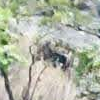

In [ ]:
left = 100
upper = 50
right = 200
lower = 150
cropped_image = image_colored.crop((left, upper, right, lower))
display(cropped_image)

**Saving NumPy Array to Image.**

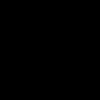

In [ ]:
image_array = np . zeros ((100 , 100 , 3) , dtype = np . uint8 )
image_from_array = Image . fromarray ( image_array )
image_from_array . show ()
display ( image_from_array )

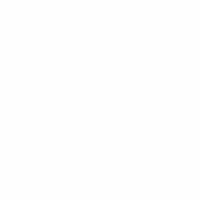

In [ ]:
image_array = np . ones ((200 , 200 , 4) , dtype = np . uint8 )
image_from_array = Image . fromarray ( image_array )
image_from_array . show ()
display ( image_from_array )

In [ ]:
image_from_array = image_from_array.convert("RGB")
image_from_array.save ("output_image.jpg")

**Principal Component Analysis (PCA)**

In [ ]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image

image = Image.open("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Image.JPG"). convert ('L')

image_array = np.array (image)
height , width = image_array . shape

data = image_array . reshape ( height , width )
display (image)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
mean = np . mean ( data , axis =0)
centered_data = data - mean
centered_data = centered_data

In [ ]:
cov_matrix = np . cov ( centered_data , rowvar = False )


In [ ]:
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]
display(sorted_indices)

array([1535, 1534, 1533, ...,    2,    1,    0])

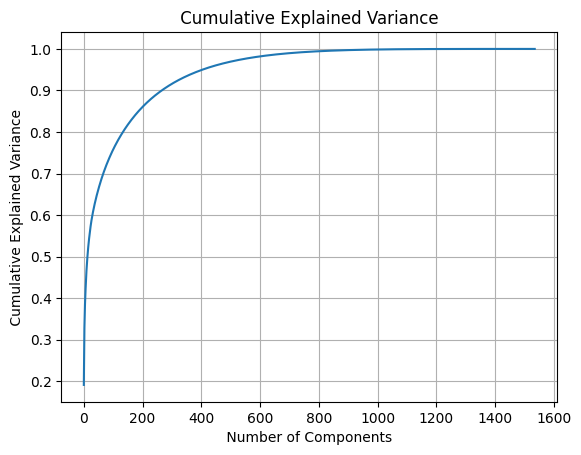

In [ ]:
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [ ]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [ ]:
compressed_data = np . dot ( centered_data , components )

In [ ]:
decompressed_data = np . dot ( compressed_data , components . T ) + mean

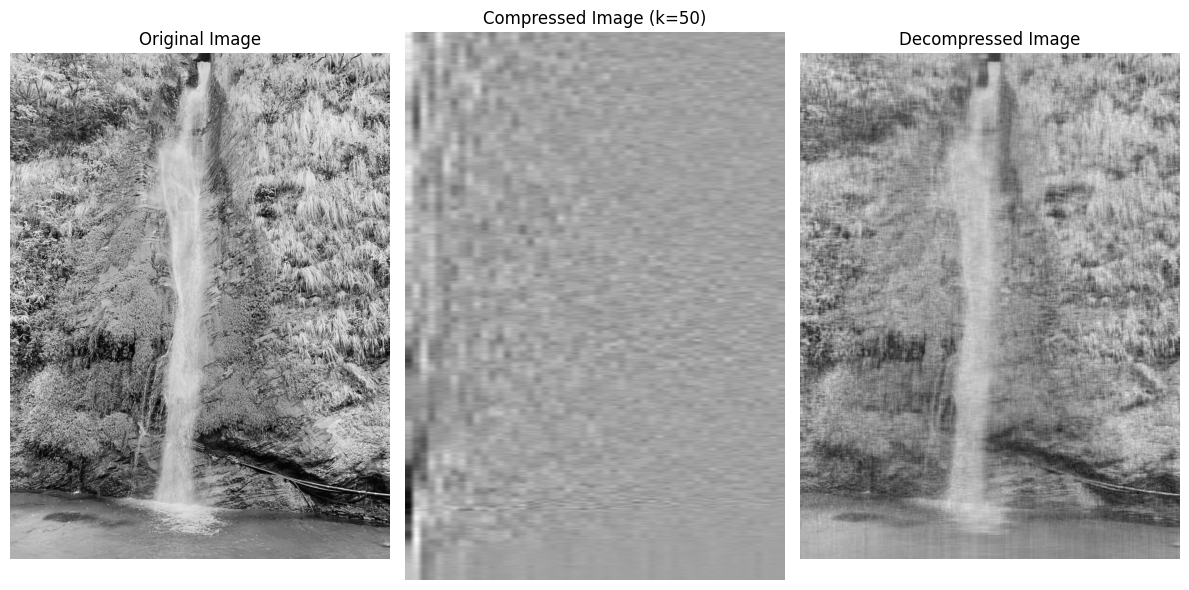

In [ ]:
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()